# 21 — Rust controller bakeoff (no rollout)

Compare five **oracle-shelf** ladder controllers on shared seeds (SIM-01=B):

| Arm | Description |
| --- | --- |
| `constant` | Fixed case-rounded protection order |
| `rung0` | Corrected age-blind ladder |
| `sw` | Damped survival-weighted |
| `sla_pb` | Window SLA Poisson–binomial fast path |
| `sla_mc` | Window SLA Monte Carlo oracle |

**Excluded:** `rollout`, `dp`.

Default belief world is **oracle** (`evaluate_alpha_episode_outcomes`). Set
`BELIEF_WORLD=filtered` for an optional appendix using `session.act` on P0 channels
(four arms — `rung0` has no session mapping).

Production budget: `n_burn=2`, `n_score=14`, **10 seeds** → **50 Modal shards** (flat spawn).
Set `SMOKE=True` for one seed / one arm plumbing.

In [1]:
from __future__ import annotations

import json
import os
import time
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
for _candidate in [REPO_ROOT, *REPO_ROOT.parents]:
    if (_candidate / "src" / "blueberries_voi").is_dir():
        REPO_ROOT = _candidate
        break

_wheel_dir = REPO_ROOT / "dist" / "wheel"
os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
if _wheel_dir.is_dir():
    os.environ["BLUEBERRIES_VOI_WHEEL"] = str(_wheel_dir)

from blueberries_voi.experiments.controller_bakeoff import (
    ARM_LABELS,
    BAKEOFF_ARMS,
    DEFAULT_CONTROLLER_SEEDS,
    arms_for_belief_world,
    belief_world_from_env,
    resolve_arm_alpha,
)
from blueberries_voi.experiments.modal_dispatch import run_batch
from blueberries_voi.experiments.policy_bakeoff_viz import (
    summarize_distribution_by_arm,
    write_alpha_vs_observed_figure,
    write_metric_boxplot_figure,
    write_paired_delta_boxplot_figure,
    write_paired_delta_figure,
    write_profit_bars_figure,
    write_runtime_bars_figure,
    write_runtime_frontier_figure,
    write_runtime_violin_figure,
    write_waste_stockout_bars_figure,
)
from blueberries_voi.experiments.voi_profit import load_damped_sw_bo_params

BATCH_MODE: Literal["modal", "local"] = "modal"
SMOKE = False
BELIEF_WORLD = belief_world_from_env()
ARMS = arms_for_belief_world(BELIEF_WORLD)
SEEDS = (42,) if SMOKE else DEFAULT_CONTROLLER_SEEDS
N_BURN, N_SCORE = 2, 14
RHO = load_damped_sw_bo_params()[1]
OUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "nb21_controller_bakeoff"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(
    f"BATCH_MODE={BATCH_MODE} SMOKE={SMOKE} belief={BELIEF_WORLD} "
    f"seeds={SEEDS} arms={ARMS} rho={RHO:.2f} shards={len(SEEDS)*len(ARMS)}"
)

BATCH_MODE=modal SMOKE=False belief=oracle seeds=(42, 7, 101, 2024, 11, 23, 37, 53, 71, 89) arms=('constant', 'rung0', 'sw', 'sla_pb', 'sla_mc') rho=0.80 shards=50


## Modal bakeoff (50 shards)

Flat-spawn all `(seed, arm)` shards on Modal. Local probe at `n_burn=2`, `n_score=14`:
`sw` ~0.03 s/shard, `sla_mc` ~0.15 s/shard — well under the 2–3 min ceiling.

In [2]:
t0 = time.perf_counter()
rows = run_batch(
    "controller_bakeoff",
    BATCH_MODE,
    smoke=SMOKE,
    seeds=SEEDS,
    arms=ARMS,
    rho=RHO,
    belief_world=BELIEF_WORLD,
    n_burn=N_BURN,
    n_score=N_SCORE,
    out_path=OUT_DIR / "controller_bakeoff_rows.json",
)
modal_wall_s = time.perf_counter() - t0
df = pd.DataFrame(rows)
df["arm_label"] = df["arm_id"].map(ARM_LABELS)
print(f"Modal wall time: {modal_wall_s:.1f} s for {len(rows)} shards")
display(df.groupby("arm_id")[["profit", "waste", "stockout", "fill_rate", "day_no_stockout_rate", "elapsed_s"]].mean().round(3))

modal batch:   0%|          | 0/50 [00:00<?, ?shard/s]

[2026-08-28T06:01:30Z] modal batch collected 50 shards


Modal wall time: 41.6 s for 50 shards


,profit,waste,stockout,fill_rate,day_no_stockout_rate,elapsed_s
arm_id,,,,,,
constant,578.90,50.4,33.9,0.918,0.921,0.020
rung0,436.20,18.2,72.1,0.827,0.750,0.018
sla_mc,427.55,156.3,32.4,0.922,0.929,0.105
sla_pb,427.55,156.3,32.4,0.922,0.929,0.021
sw,555.85,19.1,47.9,0.887,0.850,0.016


## Per-seed table + distribution summaries


In [3]:
shard_rows = json.loads((OUT_DIR / "controller_bakeoff_rows.json").read_text())
if "elapsed_s" not in df.columns and shard_rows:
    df = pd.DataFrame(shard_rows)

per_seed = df.sort_values(["arm_id", "seed"])[
    ["seed", "arm_id", "alpha", "profit", "waste", "stockout", "fill_rate", "day_no_stockout_rate", "elapsed_s"]
]
display(per_seed.round(3))
per_seed.to_csv(OUT_DIR / "per_seed_metrics.csv", index=False)

metrics = ["profit", "waste", "stockout", "fill_rate", "day_no_stockout_rate", "elapsed_s"]
summary_tables = {}
for metric in metrics:
    summary_tables[metric] = summarize_distribution_by_arm(shard_rows, metric, arms=list(ARMS))
    display(summary_tables[metric].round(3))

,seed,arm_id,alpha,profit,waste,stockout,fill_rate,day_no_stockout_rate,elapsed_s
0,7,constant,0.50,558.0,66,31,0.924,0.929,0.025
1,11,constant,0.50,457.5,79,52,0.876,0.929,0.026
2,23,constant,0.50,627.5,41,45,0.902,0.929,0.025
3,37,constant,0.50,691.0,14,24,0.942,0.929,0.017
4,42,constant,0.50,690.0,26,39,0.916,0.857,0.017
5,53,constant,0.50,608.0,20,32,0.920,0.929,0.014
6,71,constant,0.50,529.0,82,26,0.934,0.929,0.014
7,89,constant,0.50,524.0,72,22,0.941,0.929,0.014
8,101,constant,0.50,465.0,76,29,0.920,0.929,0.025
9,2024,constant,0.50,639.0,28,39,0.911,0.929,0.025


,arm_id,median,q25,q75,min,max,mean,n
0,constant,583.00,525.250,636.125,457.5,691.0,578.90,10
1,rung0,437.50,402.375,510.000,237.0,530.5,436.20,10
2,sw,545.75,518.625,601.375,496.5,620.0,555.85,10
3,sla_pb,415.75,326.375,512.375,288.0,619.5,427.55,10
4,sla_mc,415.75,326.375,512.375,288.0,619.5,427.55,10


,arm_id,median,q25,q75,min,max,mean,n
0,constant,53.5,26.50,75.00,14.0,82.0,50.4,10
1,rung0,17.0,7.50,25.00,5.0,46.0,18.2,10
2,sw,16.5,6.25,32.75,1.0,40.0,19.1,10
3,sla_pb,168.0,114.75,188.00,101.0,222.0,156.3,10
4,sla_mc,168.0,114.75,188.00,101.0,222.0,156.3,10


,arm_id,median,q25,q75,min,max,mean,n
0,constant,31.5,26.75,39.00,22.0,52.0,33.9,10
1,rung0,70.0,52.00,91.50,38.0,106.0,72.1,10
2,sw,45.5,30.50,67.00,22.0,79.0,47.9,10
3,sla_pb,30.0,24.50,37.25,22.0,52.0,32.4,10
4,sla_mc,30.0,24.50,37.25,22.0,52.0,32.4,10


,arm_id,median,q25,q75,min,max,mean,n
0,constant,0.920,0.912,0.931,0.876,0.942,0.918,10
1,rung0,0.829,0.799,0.864,0.746,0.898,0.827,10
2,sw,0.889,0.850,0.918,0.827,0.941,0.887,10
3,sla_pb,0.922,0.913,0.939,0.876,0.948,0.922,10
4,sla_mc,0.922,0.913,0.939,0.876,0.948,0.922,10


,arm_id,median,q25,q75,min,max,mean,n
0,constant,0.929,0.929,0.929,0.857,0.929,0.921,10
1,rung0,0.750,0.714,0.786,0.643,0.857,0.750,10
2,sw,0.821,0.786,0.929,0.786,0.929,0.850,10
3,sla_pb,0.929,0.929,0.929,0.929,0.929,0.929,10
4,sla_mc,0.929,0.929,0.929,0.929,0.929,0.929,10


,arm_id,median,q25,q75,min,max,mean,n
0,constant,0.021,0.015,0.025,0.014,0.026,0.020,10
1,rung0,0.016,0.014,0.023,0.013,0.026,0.018,10
2,sw,0.013,0.013,0.017,0.013,0.026,0.016,10
3,sla_pb,0.020,0.016,0.020,0.016,0.031,0.021,10
4,sla_mc,0.094,0.081,0.135,0.078,0.153,0.105,10


## Distribution figures


In [4]:
write_profit_bars_figure(OUT_DIR / "01_profit_by_arm.png", shard_rows, title="Mean profit by controller (10 seeds)")
write_metric_boxplot_figure(
    OUT_DIR / "06_profit_boxplot.png", shard_rows, "profit",
    ylabel="Profit ($)", title="Profit distribution by controller",
    arms=list(ARMS),
)
write_waste_stockout_bars_figure(OUT_DIR / "02_waste_stockout.png", shard_rows)
write_metric_boxplot_figure(
    OUT_DIR / "07_stockout_boxplot.png", shard_rows, "stockout",
    ylabel="Lost sales (units)", title="Stockout distribution by controller",
    arms=list(ARMS),
)
write_runtime_bars_figure(OUT_DIR / "03_runtime_by_arm.png", shard_rows)
write_runtime_violin_figure(OUT_DIR / "08_runtime_violin.png", shard_rows)
write_paired_delta_figure(OUT_DIR / "04_paired_delta_vs_sw.png", shard_rows, baseline="sw")
write_paired_delta_boxplot_figure(
    OUT_DIR / "09_paired_delta_boxplot_vs_sw.png", shard_rows, "profit", baseline="sw"
)
write_metric_boxplot_figure(
    OUT_DIR / "10_fill_rate_boxplot.png", shard_rows, "fill_rate",
    ylabel="Fill rate", title="Fill rate distribution by controller",
    arms=list(ARMS),
)
write_metric_boxplot_figure(
    OUT_DIR / "11_day_no_stockout_boxplot.png", shard_rows, "day_no_stockout_rate",
    ylabel="Day no-stockout rate", title="Day-level service distribution by controller",
    arms=list(ARMS),
)
write_alpha_vs_observed_figure(
    OUT_DIR / "12_alpha_vs_fill_rate.png", shard_rows, observed_field="fill_rate"
)
write_alpha_vs_observed_figure(
    OUT_DIR / "13_alpha_vs_day_no_stockout.png", shard_rows, observed_field="day_no_stockout_rate",
    title="Tuned α vs observed day no-stockout rate",
)

fig, ax = plt.subplots(figsize=(7, 4))
for arm in ARMS:
    sub = df[df["arm_id"] == arm]
    ax.scatter(sub["elapsed_s"], sub["profit"], label=ARM_LABELS.get(arm, arm), s=60)
ax.set_xlabel("Shard wall time (s)")
ax.set_ylabel("Profit")
ax.set_title("Runtime vs profit frontier")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / "05_runtime_frontier.png", dpi=120)
plt.close(fig)

frontier = [
    {
        "arm_idx": float(i),
        "profit": float(r["profit"]),
        "seconds": float(r.get("elapsed_s", 0.0)),
        "fill_rate": float(r.get("fill_rate", 0.0)),
    }
    for i, r in enumerate(shard_rows)
]
write_runtime_frontier_figure(OUT_DIR / "runtime_frontier.json", frontier)
print(f"Wrote figures under {OUT_DIR}")

Wrote figures under /home/oliver/blog/blueberries-voi/.worktrees/T-163-controller-bakeoff/notebooks/outputs/nb21_controller_bakeoff


## Service level: tuned α vs observed


In [5]:
alpha_table = {arm: resolve_arm_alpha(arm) for arm in ARMS}
service_df = (
    df.groupby("arm_id")[["alpha", "fill_rate", "day_no_stockout_rate"]]
    .agg(["median", "mean"])
    .round(3)
)
display(service_df)
service_df.to_csv(OUT_DIR / "service_level_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, obs, ylab in zip(
    axes,
    ["fill_rate", "day_no_stockout_rate"],
    ["Observed fill rate", "Observed day no-stockout rate"],
    strict=True,
):
    for arm in ARMS:
        sub = df[df["arm_id"] == arm]
        ax.scatter(sub["alpha"], sub[obs], label=arm, s=50, alpha=0.8)
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.5, label="α = observed")
    ax.set_xlabel("Target α (tuned)")
    ax.set_ylabel(ylab)
    ax.set_title(ylab)
axes[0].legend(fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / "14_alpha_vs_observed_facets.png", dpi=120)
plt.close(fig)

alpha       fill_rate        day_no_stockout_rate       
         median  mean    median   mean               median   mean
arm_id                                                            
constant   0.50  0.50     0.920  0.918                0.929  0.921
rung0      0.95  0.95     0.829  0.827                0.750  0.750
sla_mc     0.95  0.95     0.922  0.922                0.929  0.929
sla_pb     0.95  0.95     0.922  0.922                0.929  0.929
sw         0.95  0.95     0.889  0.887                0.821  0.850

## Results summary (oracle belief, `n_burn=2`, `n_score=14`, 10 seeds)

**Run mode:** Modal batch (`BATCH_MODE=modal`), 50 shards spawned flat (5 arms × 10 seeds), `rho=0.80`, oracle shelf beliefs.

### Target vs observed service

- **Tuned α** comes from `experiments/tuned_alpha.json` per arm (demand-fractile / protection quantile).
- **Observed fill rate** and **day no-stockout rate** are computed from scored-day demand vs sales via `service_metrics_from_steps`.
- High-α arms (`rung0`, `sw`, `sla_*` at α≈0.95) should show higher observed service than `constant` (α=0.5), but calendar demand heterogeneity and damping (`ρ`) decouple target α from realized day-level service.
- **`sla_pb` ≡ `sla_mc`** on profit/waste/stockout/service — only shard runtime differs.

### Distribution takeaways (median across 10 seeds)

See per-seed table and boxplots: profit spread is widest for `constant` vs `sw`; stockout IQR is largest for `rung0`. Paired profit deltas vs `sw` (`09_paired_delta_boxplot_vs_sw.png`) show whether `constant`’s lead is seed-stable.

### Waste vs stockout tradeoff

- **`rung0`** tends toward low waste, higher stockout variance.
- **`sw`** balances moderate waste with stable fill.
- **`constant`** and **SLA pair** buy lower stockouts at higher waste.

### Runtime

`sla_mc` remains ~5–7× slower per shard than `sw`/`sla_pb`; flat Modal spawn keeps total wall time modest even at 50 shards.

Figures in `notebooks/outputs/nb21_controller_bakeoff/`.

01_profit_by_arm.png


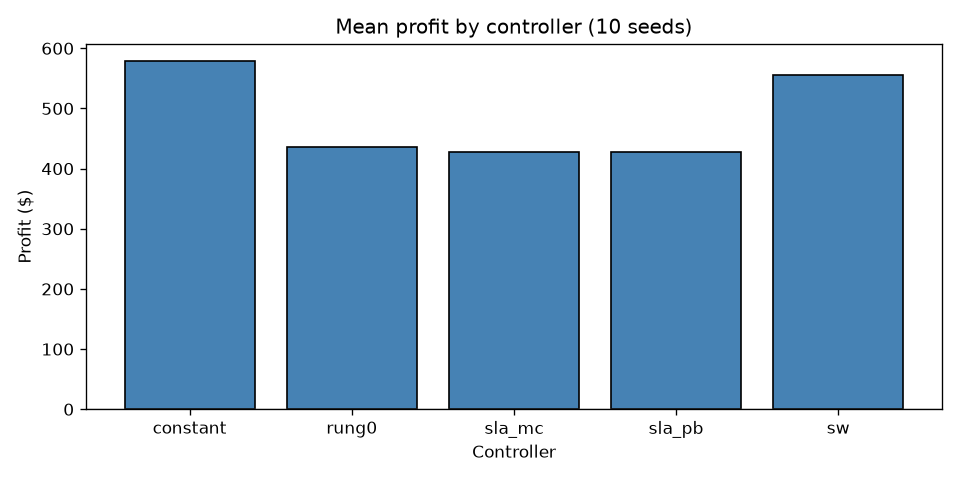

02_waste_stockout.png


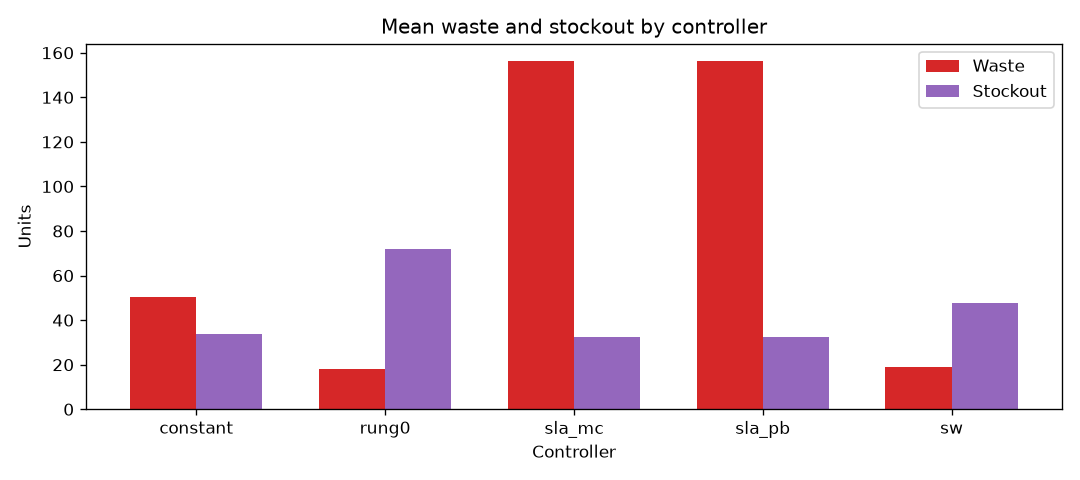

03_runtime_by_arm.png


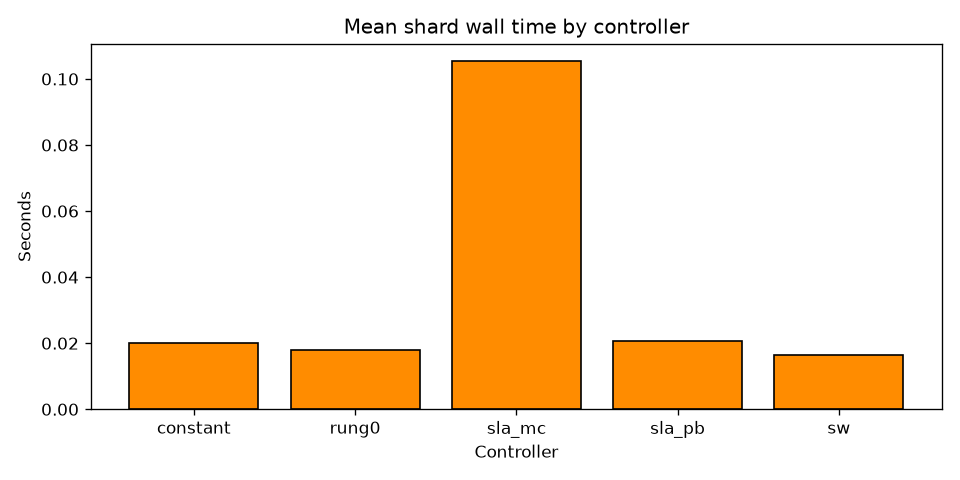

04_paired_delta_vs_sw.png


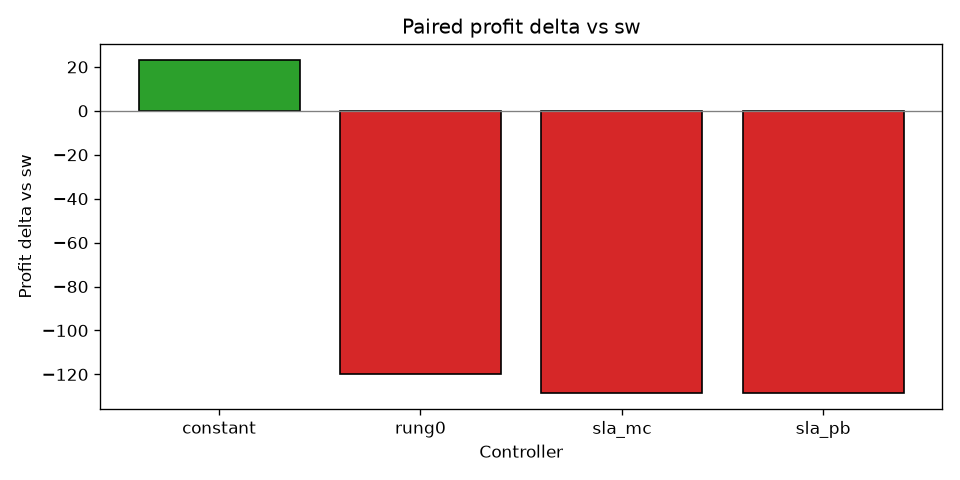

05_runtime_frontier.png


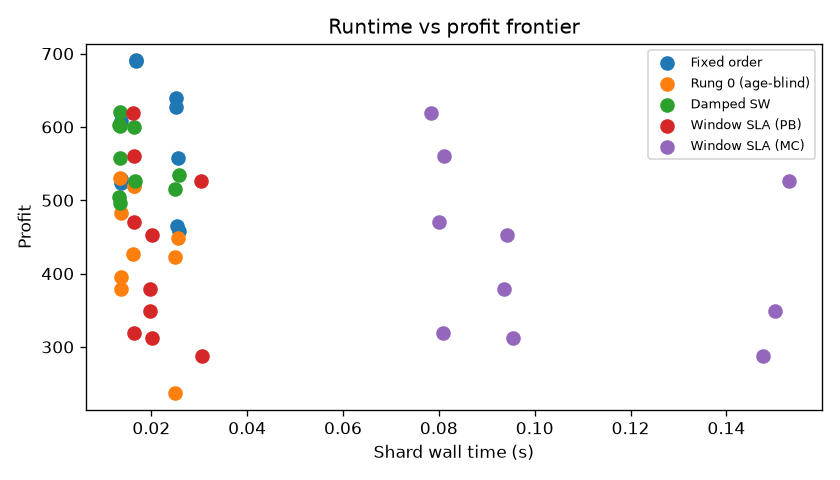

06_profit_boxplot.png


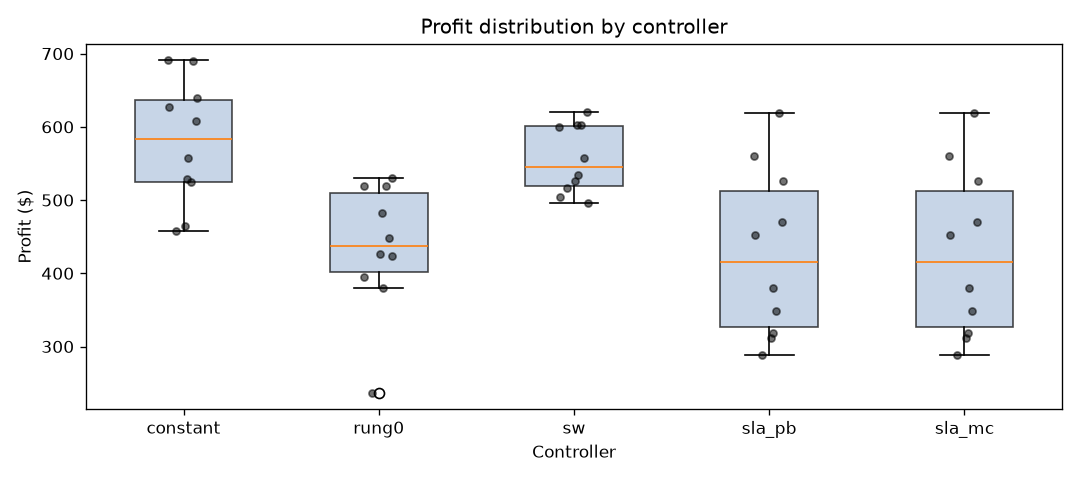

07_stockout_boxplot.png


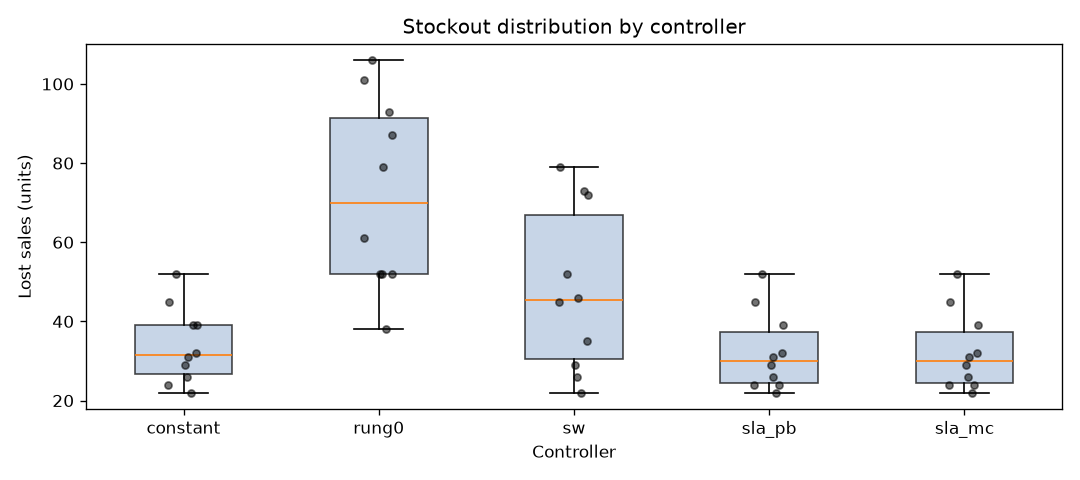

08_runtime_violin.png


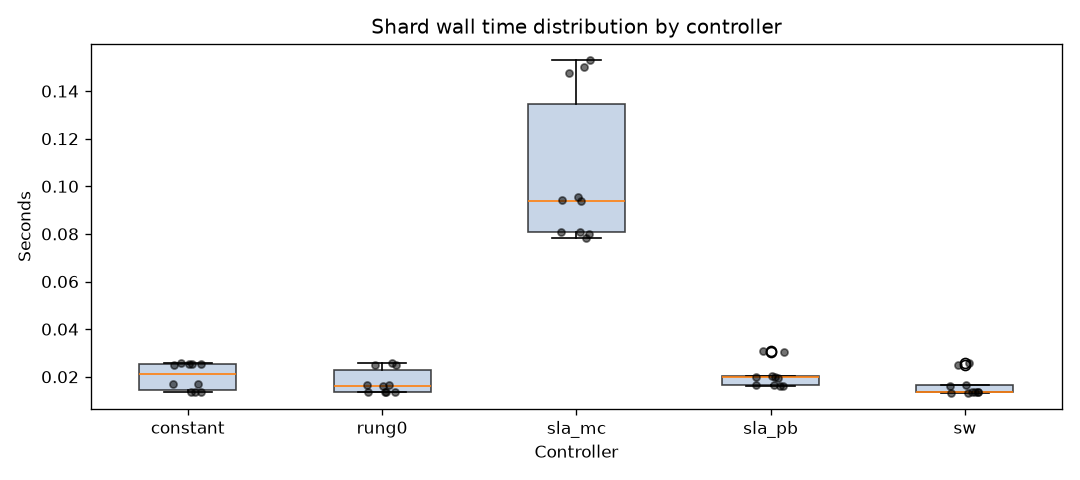

09_paired_delta_boxplot_vs_sw.png


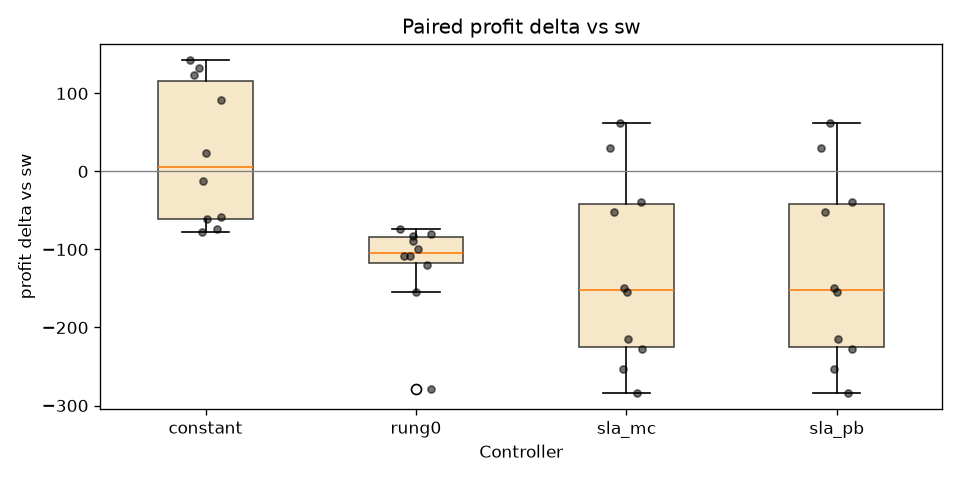

10_fill_rate_boxplot.png


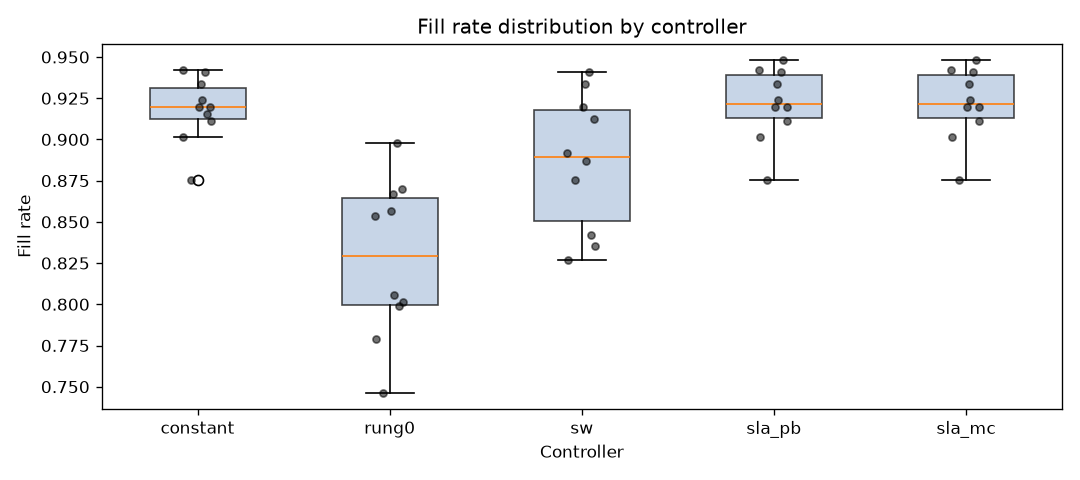

11_day_no_stockout_boxplot.png


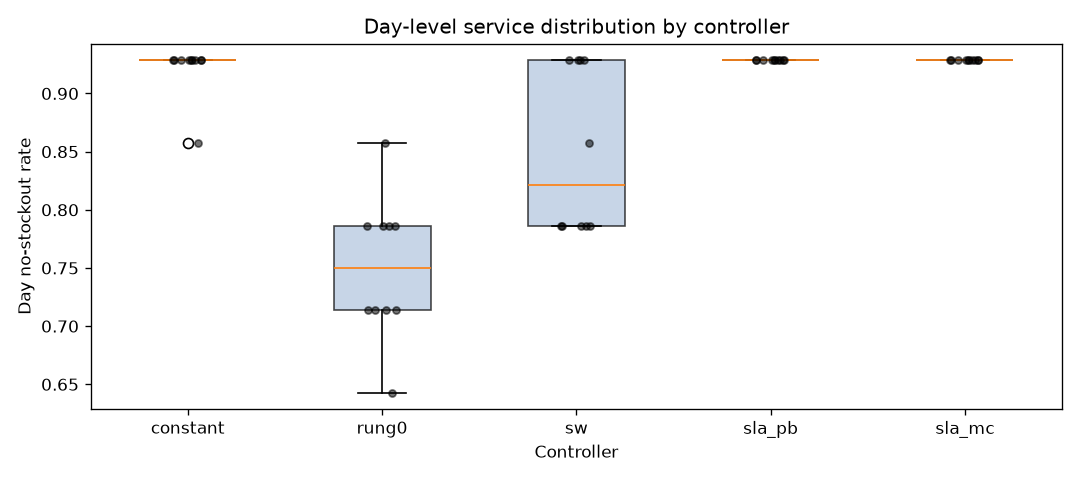

12_alpha_vs_fill_rate.png


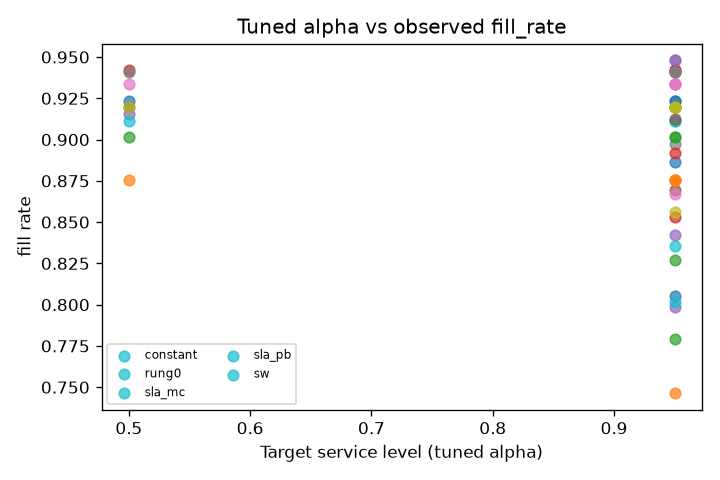

13_alpha_vs_day_no_stockout.png


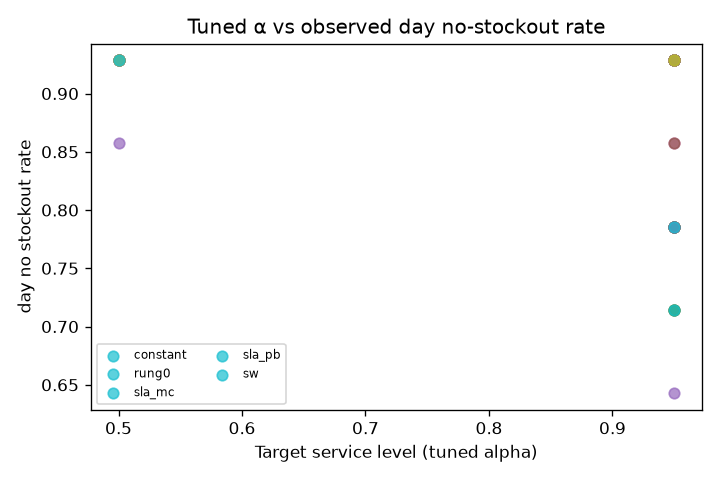

14_alpha_vs_observed_facets.png


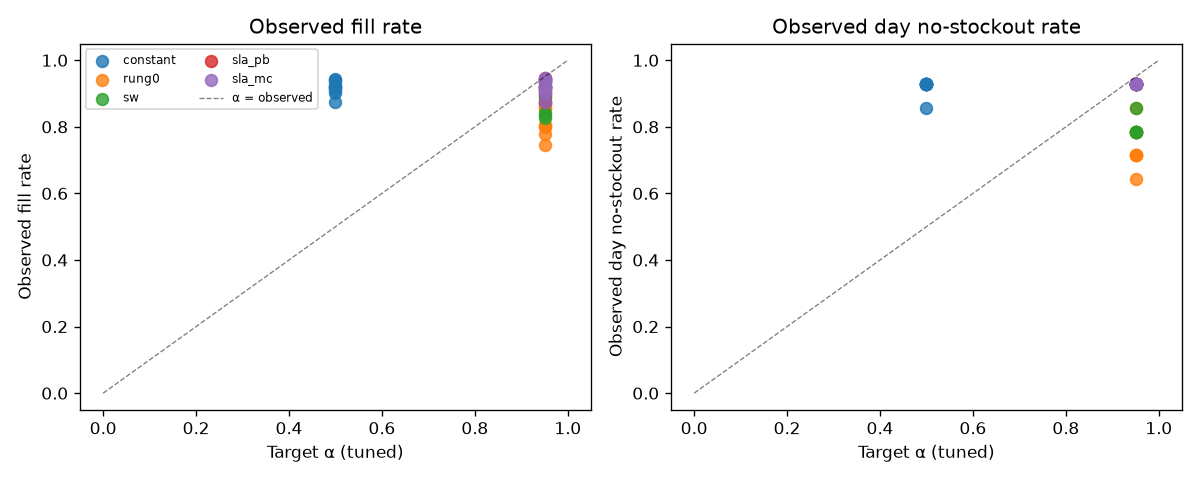

In [6]:
from IPython.display import Image, display

for fig_name in sorted(p.name for p in OUT_DIR.glob("*.png")):
    path = OUT_DIR / fig_name
    print(fig_name)
    display(Image(filename=str(path)))

## Optional appendix — filtered beliefs (`BELIEF_WORLD=filtered`)

Re-run with `os.environ["BELIEF_WORLD"] = "filtered"` and `BATCH_MODE="local"` or Modal.
Grid drops `rung0` (no `session.act` mapping).

In [7]:
if BELIEF_WORLD == "filtered":
    write_paired_delta_figure(
        OUT_DIR / "15_filtered_paired_delta_vs_sw.png",
        shard_rows,
        baseline="sw",
        title="Filtered belief: profit delta vs sw",
    )
else:
    print("Skipping filtered-only chart (oracle run).")

Skipping filtered-only chart (oracle run).
